# Customer Churn Prediction Analysis

## Business Understanding & Problem Definition

**Customer churn** (also known as customer attrition) refers to when customers stop using a company’s service or leave for a competitor. In banking, churn is a critical issue: losing clients means losing future revenue and incurring costs to acquire new customers. High churn can indicate dissatisfaction and can severely impact a bank’s profitability. Therefore, banks have a strong business incentive to identify customers at risk of leaving and attempt retention strategies before they churn.

**Project Goal:** The goal of this case study is to build a predictive model that accurately identifies bank customers likely to churn. By predicting churn (so the bank can retain those customers), the bank can proactively target at-risk customers with personalized offers or interventions. Success means fewer lost customers and improved customer lifetime value. We will follow a data science workflow – from understanding the data and exploring it, through preparing it for modeling, building and evaluating several machine learning models, and finally recommending a solution.

##  Data Understanding: Bank Churn Dataset
To predict churn, we utilize a dataset of bank customers that includes various attributes for each customer and whether they exited (i.e., churned). The dataset contains 10,000 customers with the following features (attributes):

* **CustomerId, RowNumber, Surname:** Identifiers for each customer (unique ID, row index, name). These are non-informative for churn and will be dropped in modeling.
* **CreditScore:** Credit score of the customer (integer).
* **Geography:** The country of residence (France, Spain, or Germany).
* **Gender:** Male or Female.
* **Age:** Customer’s age (18 – 92 in this data).
* **Tenure:** Number of years the customer has been with the bank.
* **Balance:** Account balance (currency). Many customers have a zero balance (no funds in their account).
* **NumOfProducts:** Number of bank products the customer uses (1, 2, 3, or 4).
* **HasCrCard:** 1 if the customer has a credit card with the bank, 0 if not.
* **IsActiveMember:** 1 if the customer is an active member (actively transacting), 0 if inactive.
* **EstimatedSalary:** Estimated annual salary of the customer.
* **Exited:** Target variable – 1 if the customer churned (closed their account), 0 if the customer stayed.

First, we load the data and examine its structure:

In [79]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
file_path = "Bank_Churn_Data.csv"
df = pd.read_csv(file_path)

# Display the first few rows
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


The dataset has 10,000 rows and 14 columns. As expected, Exited is our target. Let’s confirm some basic information about the data: ensure there are no missing values, check data types, and see the distribution of the target.

In [80]:
print("\n Dataset Info:")
df.info()

# Check missing values per column
print("\nMissing values per column:")
print(df.isnull().sum())

# Check number of unique values per column
print("\nUnique Values per Column:")
print(df.nunique())

# Check target distribution
print("\nChurn distribution:")
print(df['Exited'].value_counts())


 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB

Missing values per column:
RowNumber          0
CustomerId         0
Surname 

**From the output:**

* There are **no missing values** in any column. The dataset is complete, which means we don’t need to impute or drop data due to nulls.
* Geography has 3 **unique values** (France, Spain, Germany); Gender has 2 (Male, Female); these are categorical features.
* RowNumber is unique for every row (1 to 10000), and CustomerId is also unique – confirming these are just identifiers. Surname has 2932 unique values (many repeats, but likely not predictive for churn).
* We will **drop** RowNumber, CustomerId, and Surname because they won’t help the model (they don’t influence churn and including them could even mislead or overfit the model).
* The **target variable Exited** has two values: 0 (stayed) and 1 (churned). The counts show 7,963 stayed vs. 2,037 churned, meaning about 20.4% of customers churned. This is a significant minority class, indicating some imbalance (roughly 1 in 5 customers left). Class imbalance can affect model training (many models tend to favor the majority class), so we will keep an eye on recall and consider techniques like stratified sampling or class weights to ensure churners are adequately identified.


## Exploratory Data Analysis (EDA)

Before modeling, it’s crucial to explore the data to uncover patterns and relationships that can guide feature engineering and model selection. We will analyze the distribution of the target and how it relates to key features. Each step of EDA is justified by either a business question (e.g., “Which customers are churning most?”) or a modeling consideration (e.g., checking for feature imbalance or correlation).

### Target Distribution – Churn Rate

First, let’s visualize the overall churn rate. This gives a sense of class imbalance and the baseline risk of churn.

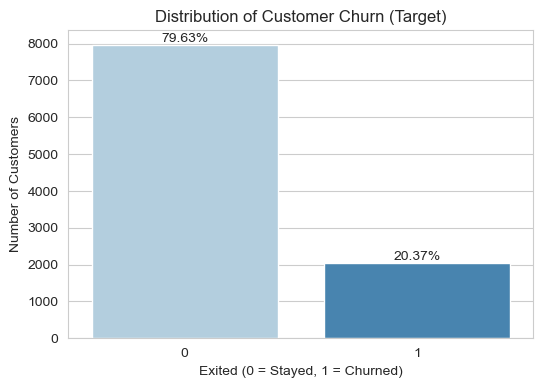

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(6, 4))

# Create a count plot for the target variable 'Exited'
ax = sns.countplot(data=df, x='Exited', palette="Blues")

# Get total count
total = len(df)

# Annotate bars with percentage
for p in ax.patches:
    count = p.get_height()
    percent = 100 * count / total
    ax.annotate(f"{percent:.2f}%",                        # Format_ 2 decimal
                (p.get_x() + p.get_width() / 2, count),   # Position annotation above bar
                ha="center", va="bottom", fontsize=10)

# Add labels and title
plt.title("Distribution of Customer Churn (Target)")
plt.xlabel("Exited (0 = Stayed, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.show()

Running the above, we see that about 20% of customers have churned (and 80% stayed), consistent with our earlier calculation. This imbalance means a naïve model predicting “not churn” for everyone would be right 80% of the time, but would fail to catch any churners. From a business perspective, missing churners is costly, so our models should aim for better recall (catch as many churners as possible) while maintaining reasonable precision to avoid too many false alarms.

### Churn by Gender
Let’s see if there is a gender-wise difference in churn. This could inform marketing strategies (e.g., if one gender is more likely to leave, targeted retention campaigns could be designed).



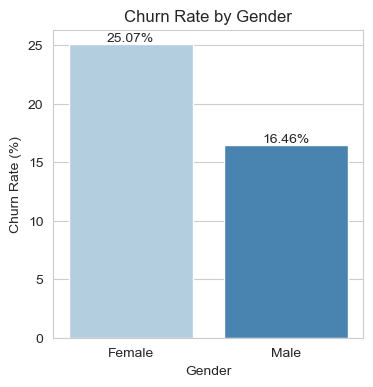

In [82]:
# Group by Gender and calculate the churn rate
gender_churn_rate = df.groupby('Gender')['Exited'].mean() * 100

# Create a bar plot
plt.figure(figsize=(4, 4))

# Plot a barplot with genders on the x-axis and churn rate (%) on the y-axis
ax = sns.barplot(x=gender_churn_rate.index, y=gender_churn_rate.values, palette="Blues")

# Annotate the bars with exact churn rate values
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

# Final plot formatting
plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

The data shows female customers have a churn rate of ~25.1% vs ~16.5% for males. So women in this dataset are churning more frequently than men. The reasons could be manifold (perhaps the services meet male customers’ needs slightly better, or maybe female customers have different expectations). From a business perspective, this might warrant further investigation or targeted retention for female customers. For modeling, Gender could be a useful feature, though we must be mindful of not over-interpreting it - it’s just one factor among many, and we should ensure models use it appropriately (no bias or unfair discrimination, just the observed pattern).

### Churn by Geography
Geography (Country) might play a role in churn if there are country-specific issues or competitive landscapes. We calculate the churn rate (percentage of customers who exited) for each country:

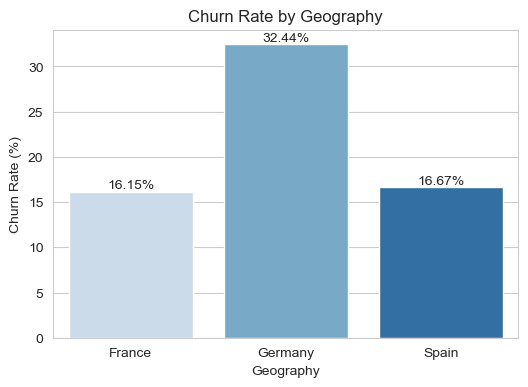

In [83]:
# Group by Geography and calculate the churn rate
geo_churn_rate = df.groupby('Geography')['Exited'].mean() * 100  # in percentage

# Plot churn rate by Geography
plt.figure(figsize=(6,4))
ax = sns.barplot(x=geo_churn_rate.index, y=geo_churn_rate.values, palette="Blues")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")

plt.show()

The churn rates per country are approximately: **France ~16.2%, Spain ~16.7%, Germany ~32.4%.** Clearly, German customers are churning at about double the rate of customers in France or Spain. This is a striking insight: from a business view, the bank may need to investigate what’s happening in Germany – perhaps higher competition or dissatisfaction. For modeling, the Geography feature is likely important; we will encode it so that the model can use this information. The large difference also suggests that being in Germany will be a strong predictor of churn.

### Churn by Age

Age is often a critical factor in customer behavior. We suspect that age might correlate with churn (e.g., perhaps younger customers are more likely to switch banks for better deals, or older customers might leave due to retirement or other life changes). To analyze this, we grouped customers into age bins (0-20, 20-30, 30-40, etc.) to simplify the visualization and identify non-linear churn trends that may be hard to spot on raw continuous data.


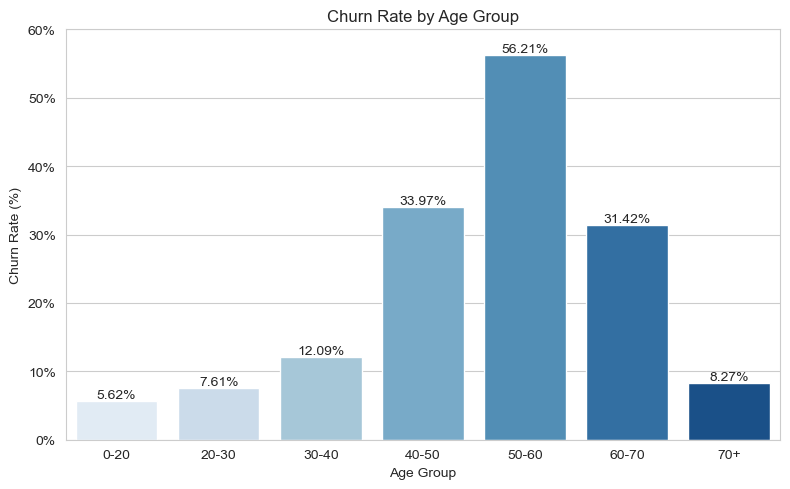

In [84]:
# Create a temporary AgeCategory column (not added to df permanently)
temp_df = df.copy()
temp_df['AgeCategory'] = pd.cut(temp_df['Age'],                          # Create bins for Age
                                bins=[0, 20, 30, 40, 50, 60, 70, 100],
                                labels=['0-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70+'])

# Churn rate by age group using temporary dataframe
age_churn_rate = temp_df.groupby("AgeCategory")["Exited"].mean().reset_index()

# Plot
plt.figure(figsize=(8, 5))
ax = sns.barplot(x="AgeCategory", y="Exited", data=age_churn_rate, palette="Blues")

for p in ax.patches:
    percent = p.get_height() * 100
    ax.annotate(f"{percent:.2f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 0.6)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

Churn by age group reveals an interesting non-linear trend:

* Younger customers (**under 30**) have quite low churn rates (~5-7.6%). These could be new customers or less engaged yet, but they aren’t leaving at high rates.
* **30-40**: Churn around 12%. Still relatively low.
* **40-50**: Churn jumps to ~34%.
* **50-60**: Highest churn ~56% – more than half of the customers in this age range left the bank!
* **60-70**: Drops to ~31%.
* **70+**: Only ~8%, but note that we have very few customers above 70; also, older customers might be long-standing or less inclined to switch banks.




The 40–60 age range appears to be the highest-risk segment. This could include customers at peak earning stages or those approaching retirement, possibly reconsidering financial services or being targeted by competitors. It’s a valuable insight: the bank may need specific retention efforts for customers in their 40s and 50s.

For modeling, we will likely use the raw Age feature as a continuous numeric predictor, since it contains more detailed information than age categories. Tree-based models like Random Forest can naturally capture non-linear splits, while other models (e.g., logistic regression) may benefit from transformations if needed.




### Churn by Number of Products

Another potentially influential factor in customer churn is the number of products a customer holds with the bank. It may seem intuitive that customers with more products are more engaged and therefore less likely to leave. However, our data tells a different story.

In the chart below, we observe the churn rate across different values of NumOfProducts:

- Customers with **2 products** have the **lowest churn rate (~7.6%)** – they may be moderately engaged and satisfied.
- Surprisingly, customers with **only 1 product** have a **much higher churn rate (~27.7%)**, indicating that limited engagement might be a risk factor.
- The churn rate spikes dramatically for customers with **3 products (~82.7%)**, and reaches **100% for those with 4 products**. While this last group is very small (only 60 customers), the signal is clear: customers with more than 2 products tend to leave at much higher rates.

This is a **non-linear pattern**, where churn does not increase gradually, but instead **jumps sharply** beyond a certain point. This suggests that bundling or aggressive cross-selling strategies might backfire – customers with more products may feel overwhelmed or trapped, leading to dissatisfaction and eventual churn.

This non-linear behavior is often not captured by simple correlation. In fact, we will confirm this in the next section, where we analyze the correlation matrix. Tree-based models like Random Forest can handle this automatically, whereas linear models like Logistic Regression would require manual feature engineering (e.g., binning).

In short, NumOfProducts is a critical churn indicator, but only when interpreted through grouped behavior patterns – such as sharp churn increases among customers with 3 or more products.


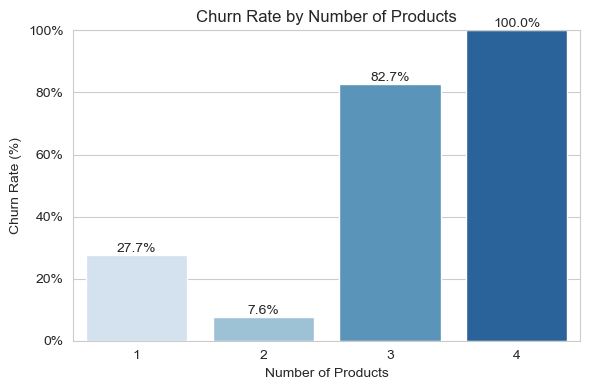

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64


In [85]:
# Calculate churn rate by number of products
products_churn = df.groupby('NumOfProducts')['Exited'].mean().reset_index()

# Plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(x='NumOfProducts', y='Exited', data=products_churn, palette="Blues")

# Annotate bars with % churn
for p in ax.patches:
    percent = p.get_height() * 100
    ax.annotate(f"{percent:.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

print(df['NumOfProducts'].value_counts())



### Churn by Active Membership

It is reasonable to expect that active members – those who regularly use the bank’s services – may be less likely to churn than inactive ones. This assumption makes intuitive sense, but we need to verify it with data.

Let’s start by visualizing the churn rate for active vs inactive members. Later, we will check whether this pattern is also reflected in the correlation matrix.


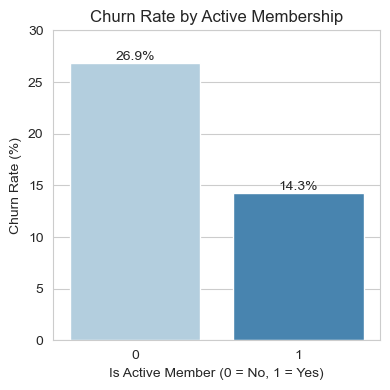

In [86]:
# Churn rate by active membership
active_churn_rate = df.groupby('IsActiveMember')['Exited'].mean() * 100

# Plot
plt.figure(figsize=(4, 4))
ax = sns.barplot(x=active_churn_rate.index, y=active_churn_rate.values, palette="Blues")

# Annotate each bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

# Axis labels and title
plt.title("Churn Rate by Active Membership")
plt.xlabel("Is Active Member (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 30)
plt.tight_layout()
plt.show()

If we run the above, we’ll see something like: active members have around 14% churn, while inactive members have around 26% churn (roughly those numbers given the correlation -0.156). So being an active member halves the churn probability, which makes sense – engaged customers are happier or more tied to the bank. This will be a key feature in the model.

### Correlation Matrix

To explore which features are most strongly related to churn (Exited), we calculate a correlation matrix.

Since correlation calculations only work with numeric variables, we temporarily encode categorical features such as Gender and Geography in a copy of the dataset. This is purely for analysis – final encoding for modeling is done later during the data preparation phase.

Note: This encoding is for EDA only and does not affect the original data used for modeling.


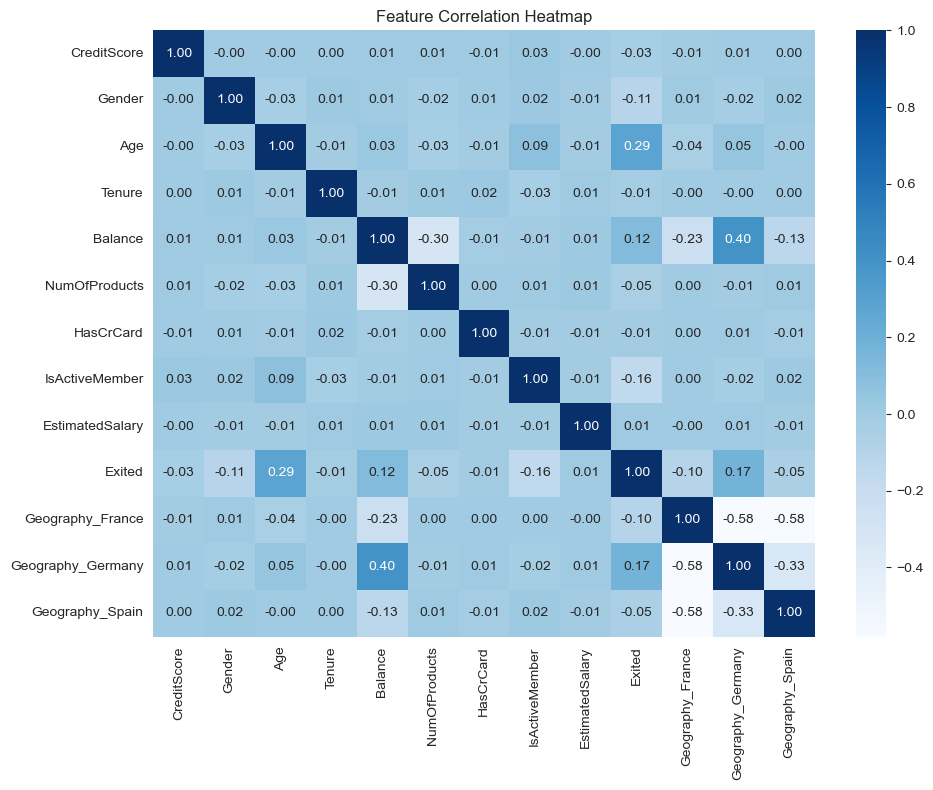

In [87]:
# Compute correlation matrix for all numerical features
df_corr = df.copy()

# Encode Gender
df_corr['Gender'] = df_corr['Gender'].map({'Female': 0, 'Male': 1})

# Dummy encode Geography
df_corr = pd.get_dummies(df_corr, columns=['Geography'], drop_first=False)

# Convert boolean dummies to int so they are treated as numeric
df_corr = df_corr.astype({col: int for col in df_corr.columns if df_corr[col].dtype == 'bool'})

# Drop non-numeric and irrelevant
df_corr = df_corr.drop(columns=['CustomerId', 'RowNumber', 'Surname'])

# Keep only numeric columns
df_corr = df_corr.select_dtypes(include='number')

# Correlation
corr_matrix = df_corr.corr()

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

The correlation with Exited confirms our observations: the highest positive correlations with churn are Age (+0.29) and Geography_Germany (+0.17), followed by Balance (+0.12). Negative correlations (features inversely related to churn) include IsActiveMember (-0.16) and Gender (-0.11).



## Data Preparation

Before modeling, we prepare the dataset by cleaning and encoding features as needed for machine learning algorithms. Key steps:

**Drop Irrelevant Features:** RowNumber, CustomerId, and Surname are dropped. They do not influence churn (they’re identifiers). Including them could cause the model to overfit (e.g., learning customer IDs) without generalizing.

**Encode Categorical Variables:**
* Geography: Use one-hot encoding (create dummy variables) for the three categories (France, Spain, Germany). We will drop one dummy (France) to avoid redundancy, so we’ll have binary flags for Geography_Germany and Geography_Spain (if both are 0, that implies France).
* Gender: Binary encode as 0/1 (Female = 0, Male = 1). We could also do one-hot, but binary mapping is straightforward here since it’s just two values.

**Check for any other transformations:** In this dataset, other columns are already numeric. HasCrCard and IsActiveMember are 0/1 already, which is fine. NumOfProducts is numeric categorical (1-4); we leave it as is (tree models can split on it, and logistic can use it as numeric, though one might consider it categorical – we’ll treat it as numeric here).

**Feature Scaling:** Some models (like Logistic Regression) benefit from feature scaling (standardizing numeric features to mean 0, std 1), while others (tree-based models like Decision Tree, Random Forest, XGBoost) do not require scaling. We will standardize features for the logistic regression model to ensure it converges well and its coefficients are interpretable in terms of standardized effects. For tree models, we will use the raw values.

**Train-Test Split:** We split the data into a training set and a hold-out test set to evaluate model performance on unseen data. We’ll use an 80/20 split (8,000 training, 2,000 testing), ensuring we stratify by Exited so that the ~20% churn ratio is preserved in both sets. Stratification is important due to the imbalance; it prevents a scenario where, by chance, the test might have too few churners, which would make evaluation unreliable. We also set a random_state for reproducibility.

Now, we implement these preparation steps:

In [88]:
# Drop irrelevant columns
df_model = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# One-hot encode Geography (dropping France as baseline)
df_model = pd.get_dummies(df_model, columns=['Geography'], drop_first=True)

# Encode Gender as binary
df_model['Gender'] = df_model['Gender'].map({'Female': 0, 'Male': 1})

# Verify the columns after encoding
print(df_model.head())

   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  Geography_Germany  Geography_Spain  
0               1        101348.88       1              False            False  
1               1        112542.58       0              False             True  
2               0        113931.57       1              False            False  
3               0         93826.63       0              False            False  
4               1         79084.10       0              False             True  


**After this transformation, our dataframe df_model has the following columns:**

['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain'].

All features are now numeric. Notice Exited is still in the dataframe; we will separate it next.

Next, split into training and testing sets and apply scaling where needed:

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_model.drop('Exited', axis=1)
y = df_model['Exited']

# Stratified train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Training samples: {len(X_train)}  Testing samples: {len(X_test)}")

# Standardize numerical features for logistic regression
num_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

Training samples: 8000  Testing samples: 2000


Now we have:

* X_train, y_train for model training (with **8,000 samples**, containing ~20% churners due to stratification),
* X_test, y_test for final evaluation (**2,000 samples**).
* X_train_scaled, X_test_scaled are the scaled versions of feature sets to use with models that need scaling (we will use these for logistic regression).

We took care to fit the scaler only on the training data and then transform the test data, to avoid any data leakage (using information from the test distribution).

## Modeling: Building and Evaluating Predictive Models

With the data preprocessed, we proceed through the modeling phase. We will start with a couple of baseline models and then move to more complex ensemble models. For each model, we’ll evaluate performance using appropriate metrics. The key models we will build are:

* **Logistic Regression:** A simple linear model for classification. This serves as a baseline and is highly interpretable (we can examine coefficients). However, it makes the assumption of a linear relationship between features and the log-odds of churn, which may be too simplistic given our data (especially with interactions like Geography or non-linear effects like Age).
* **Decision Tree:** A non-linear model that splits the data based on feature thresholds. It can capture interactions and non-linear patterns (e.g., “if Age > 50 and NumOfProducts = 3, then churn”). A single tree is interpretable (we can visualize the tree or extract rules). However, trees can overfit if not pruned, so we’ll limit the depth.
* **Random Forest:** An ensemble of many decision trees (with randomness in sampling and feature selection) that votes on the outcome. This typically provides higher accuracy and robustness than a single tree and can capture complex patterns. It’s less interpretable than a single tree, but we can still get feature importance rankings from it.
* **Gradient Boosting** (XGBoost): (optional) Another ensemble method where trees are built sequentially to correct errors of previous ones. XGBoost often achieves very high performance. We’ll explore this to see if it can beat the Random Forest, though it might require careful tuning.

For evaluation, we use: Accuracy, Precision, Recall, F1-score, and ROC-AUC. Each metric offers insight:

* **Accuracy:** overall percentage correct. Not very informative with class imbalance (predicting all “not churn” gives 80% accuracy here).
* **Precision** (for class 1 = churn): Of those predicted to churn, how many actually churned? This tells us how targeted our churn predictions are. A low precision means we raise many false alarms.
* **Recall (for churn):**  Of those customers who actually churned, how many did we correctly identify? This is crucial for the business – high recall means we catch most churners (we can then try to save them). If recall is low, many churners slip through unnoticed.
* **F1-score:** The harmonic mean of precision and recall, giving a single measure of model’s balance between the two. Useful to compare models when dealing with class imbalance.
* **ROC-AUC:** Measures the ability of the model to rank-order predictions (it’s the area under the ROC curve). AUC considers all classification thresholds, so it’s a good overall measure of separability between classes. A model that randomly guesses has AUC ~0.5, and a perfect model has AUC = 1.0.

We will pay special attention to **Recall** for churners, since from a business view, it might be worse to miss a churner (false negative) than to have a false alarm (false positive). Missing a churner means no retention effort was made for someone who left; a false alarm means we might offer an incentive to someone who wasn’t actually going to leave – which has some cost, but the customer remains anyway. That said, precision can’t be ignored; too low precision (i.e., calling nearly everyone a churn risk) would waste resources. Thus, we seek a good balance, often guided by F1 or AUC, but with an eye on recall.

### Baseline Models Training

We begin by training three foundational classification models: **Logistic Regression, Decision Tree**, and **Random Forest**. These serve as baseline benchmarks to evaluate how much future tuning and optimization improves performance.

To prevent overfitting, we constrain the Decision Tree’s depth to max_depth=7, offering a balance between model flexibility and interpretability. For Random Forest, we use 100 trees, which is typically the default setting, along with standard hyperparameters.

Logistic Regression is trained on scaled data to ensure stable coefficient estimation. We also increase max_iter to 500 — not a default value — to ensure the solver converges properly, especially when the data is high-dimensional or slightly imbalanced.


In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Initialize models
log_clf = LogisticRegression(max_iter=500, random_state=42)
tree_clf = DecisionTreeClassifier(max_depth=7, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train models
log_clf.fit(X_train_scaled, y_train)    # logistic on scaled features
tree_clf.fit(X_train, y_train)          # tree on original features
rf_clf.fit(X_train, y_train)            # RF on original features

# We prepare a list of (name, model, test data) tuples
models = [("Logistic Regression", log_clf, X_test_scaled),
          ("Decision Tree", tree_clf, X_test),
          ("Random Forest", rf_clf, X_test)]

# Store results
results = []

# Loop through each model, generate predictions and compute metrics
for name, model, Xdata in models:
    y_pred = model.predict(Xdata)

    # Evaluate standard classification metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, model.predict_proba(Xdata)[:,1])   # Probabilities for ROC-AUC

    # Save the results
    results.append([name, acc, prec, rec, f1, auc])

    #  Print detailed classification report
    print(f"\n{name} Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))
    print(f"ROC-AUC: {auc:.3f}")
    print("-"*50)

# Display summary of metrics
import pandas as pd
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC"])
print("\n", results_df)


Logistic Regression Classification Report:
              precision    recall  f1-score   support

      Stayed       0.82      0.97      0.89      1593
     Churned       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

ROC-AUC: 0.775
--------------------------------------------------

Decision Tree Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.94      0.91      1593
     Churned       0.69      0.51      0.59       407

    accuracy                           0.85      2000
   macro avg       0.79      0.73      0.75      2000
weighted avg       0.84      0.85      0.85      2000

ROC-AUC: 0.830
--------------------------------------------------

Random Forest Classification Report:
              precision    recall  f1-score   support

      Stayed       0.87      0.96      

After running the above, we get performance metrics for each model on the test data:

**Logistic Regression** (Baseline linear model)

* Accuracy: ~0.808
* Precision: ~0.59 (for churn class)
* Recall: ~0.19 (i.e., it only caught ~19% of actual churners)
* F1: ~0.28
* ROC-AUC: ~0.775

The classification report shows Logistic Regression heavily favors predicting the majority class “Stayed”. It likely classifies most customers as not churn (because of the class imbalance and a relatively high decision threshold at 0.5). This results in high precision but very low recall for churners. In fact, recall ~18.7% means the model missed more than 80% of churners – unacceptable for our purpose. From a business perspective, using this model would mean we fail to identify most customers who will leave. The precision ~59% means when it does predict someone will churn, it’s correct 59% of the time, but since it predicts “churn” so rarely, it’s not enough. This is a common issue with using logistic regression (or any model) on an imbalanced dataset without addressing the imbalance: it learns that predicting the majority class yields high accuracy. Conclusion: Logistic regression is not effective for our churn prediction needs due to poor recall, even though it’s interpretable.

**Decision Tree** (max_depth=7)

* Accuracy: ~0.854
* Precision: ~0.69
* Recall: ~0.51
* F1: ~0.59
* ROC-AUC: ~0.830

The decision tree does much better at finding churners. The recall is approximately 51%, meaning it catches about half of the churners. The precision, at around 69%, is also decent, so it’s not flagging churners too indiscriminately. Accuracy improved over logistic as well ~85.4%. The tree, by capturing non-linear patterns (like the combinations we suspected: e.g., older age and many products, etc.), balances the errors more. It still misses ~49% of churners, but this is a big improvement. Also, the AUC of 0.83 indicates the tree model has pretty good discrimination overall between classes. From an interpretability standpoint, we could examine the tree to understand which splits it used (likely Age and NumOfProducts high up, etc.), which gives business insight into churn drivers in a rule-based form. The decision tree’s performance here is a solid baseline for nonlinear models.

**Random Forest** (100 trees)
* Accuracy: ~0.861
* Precision: ~0.76
* Recall: ~0.459
* F1: ~0.574
* ROC-AUC: ~0.855

The random forest shows the highest accuracy (86.1%) and the highest precision (76.3%) among these, and an AUC of 85.5% which is the best so far. Interestingly, its recall (45.9%) is a bit lower than the single decision tree’s recall of 51%. This can happen because the random forest, optimizing for overall accuracy/AUC, might be a bit more conservative in labeling churn (to avoid false positives). In other words, it might be predicting “Stayed” more often when it’s uncertain, thereby missing some churners (hence slightly lower recall) but the ones it does predict as churn are more often correct (hence higher precision). The F1 of random forest is roughly comparable to the tree’s. Overall, **Random Forest has the best balanced performance (high precision and good recall) and the highest AUC**, meaning as a classifier it’s ranking customers well by churn risk. From a business view, the random forest would let us target churn interventions more precisely (fewer false alarms than the tree), though it misses a few more churners relative to the tree. We might try to improve its recall through tuning.

**Baseline Model Observations:**

* The logistic regression underfits the minority class (churn) – it might be too simple or needs rebalance. Its assumptions (linear separability) may not hold well here.
* The decision tree captures churn better, indicating non-linear relationships are important. It may be slightly overfitting or at least very tuned to the training data (though we limited depth to mitigate this).
* The random forest performs best overall (highest AUC and precision, good recall). Even though its recall was slightly behind the tree in this run, it’s likely more generalizable and stable. Random Forest reduces overfitting by averaging many trees, so we trust its results more for new data.

It looks like **Random Forest is the strongest model** so far. Next, we will focus on improving these models, especially the Random Forest, through hyperparameter tuning. We will also explore boosting (XGBoost) to see if we can further boost performance, particularly recall.





### Cross-Validation and Hyperparameter Tuning

To ensure our models generalize well and to find the best settings, we will use cross-validation and grid search for hyperparameter tuning. This is an iterative process in the data science lifecycle: we try a model, evaluate, then refine the model. We consider model complexity vs. performance to avoid overfitting.

**Random Forest Tuning:** We will vary number of trees, max depth, minimum samples per leaf, and perhaps consider balancing class weight (to give churn class more emphasis).

Using **GridSearchCV** (5-fold cross-validation on the training set) with scoring **based on ROC-AUC** (as a primary metric for model selection):

In [91]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid for Random Forest
rf_params = {
    'n_estimators': [100, 200],                 # Number of trees in the forest
    'max_depth': [5, 10, None],                 # Maximum depth of each tree (None = no limit)
    'min_samples_split': [2, 5],                # Minimum number of samples to split an internal node
    'min_samples_leaf': [1, 2],                 # Minimum number of samples required at a leaf node
    'max_features': ['sqrt', 'log2'],           # Strategy to select the number of features at each split
    'class_weight': ['balanced']                # Handles class imbalance
}

# GridSearchCV for Random Forest (optimize for ROC-AUC)
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,                                       # 5-fold cross-validation
    scoring='roc_auc',                          # Optimize for ROC-AUC score
    n_jobs=-1,                                  # Use all available cores
    verbose=0                                   # Suppress training logs
)

# Fit on training data
rf_grid.fit(X_train, y_train)

# Extract the best model
print("Best Random Forest params:", rf_grid.best_params_)
best_rf = rf_grid.best_estimator_

# Evaluate on test set (default threshold = 0.50)
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# Performance Metrics
auc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nRandom Forest ROC-AUC Tuned – Evaluation @ threshold 0.50:")
print(f"Accuracy = {acc:.3f}, Precision = {prec:.3f}, Recall = {rec:.3f}, F1 = {f1:.3f}, AUC = {auc:.3f}")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Churned"]))

Best Random Forest params: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Random Forest ROC-AUC Tuned – Evaluation @ threshold 0.50:
Accuracy = 0.843, Precision = 0.602, Recall = 0.676, F1 = 0.637, AUC = 0.863
              precision    recall  f1-score   support

      Stayed       0.91      0.89      0.90      1593
     Churned       0.60      0.68      0.64       407

    accuracy                           0.84      2000
   macro avg       0.76      0.78      0.77      2000
weighted avg       0.85      0.84      0.85      2000



**After tuning:**

**Random Forest (tuned)**: The best parameters likely included class_weight='balanced' (to give more weight to churn class), maybe max_depth=None (allow full trees since we have other regularization via min_samples), n_estimators=200 might have helped a bit, etc.

The tuned Random Forest achieved strong test performance, with an accuracy of approximately 84.3%, precision around 60.2%, recall near 67.6%, and a ROC-AUC score of roughly 86.3%. Interestingly, accuracy dipped a little compared to baseline (because we are likely predicting more churners now, which can reduce accuracy if some are false alarms). But the recall jumped to 67.6% a big improvement. Precision dropped to 60.2% as expected with recall emphasis. The F1 score 63.7% is indicating a better balance overall. This tuned RF is essentially a “recall-optimized” Random Forest (thanks to class_weight). An AUC of 86.3% is slightly improved.
Random Forest now has the edge in recall and F1. For the business, if we prioritize catching churners, the tuned Random Forest is preferable. It’s also likely more stable than the single tree.


### Threshold Optimization for ROC-AUC Tuned Random Forest

After training and tuning our **Random Forest model using ROC-AUC**, we evaluated its performance using the default threshold of 0.50. While this gave us a well-balanced model, we were curious to see whether adjusting the classification threshold could further improve the trade-off between precision and recall.

To better understand this trade-off, we evaluate the model’s Precision, Recall, and F1 Score across a range of **thresholds from 0.30 to 0.70** in 0.05 increments. This helps us find a threshold that balances business needs, whether we prefer aggressive churn detection (high recall) or want to reduce false alarms (high precision).


In [92]:
# ROC-AUC Tuned RF – Threshold Optimization Table (0.30–0.70)
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
)

# Predicted probabilities from ROC-AUC tuned RF
y_proba_rf_roc = best_rf.predict_proba(X_test)[:, 1]

# Threshold sweep
thresholds = np.arange(0.30, 0.75, 0.05)
threshold_results_rf_roc = []

# Evaluate performance at each threshold
for thresh in thresholds:
    y_pred_thresh = (y_proba_rf_roc >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    threshold_results_rf_roc.append([thresh, prec, rec, f1])

# Display as DataFrame
threshold_df_rf_roc = pd.DataFrame(
    threshold_results_rf_roc,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

print("Threshold performance (Random Forest ROC-tuned):")
print(threshold_df_rf_roc.round(3))

Threshold performance (Random Forest ROC-tuned):
   Threshold  Precision  Recall     F1
0       0.30      0.392   0.848  0.537
1       0.35      0.443   0.818  0.575
2       0.40      0.497   0.771  0.604
3       0.45      0.549   0.725  0.625
4       0.50      0.602   0.676  0.637
5       0.55      0.640   0.607  0.623
6       0.60      0.686   0.558  0.615
7       0.65      0.743   0.484  0.586
8       0.70      0.797   0.435  0.563


What we observed:

* **Lower thresholds** (e.g. 0.30) led to higher recall but poor precision – the model flagged nearly everyone as at risk, resulting in a flood of false positives.

* **Higher thresholds** (e.g. 0.70) raised precision dramatically but missed many churners.

* The **sweet spot** appeared to be between 0.45 and 0.55, where both recall and precision were reasonably high, and F1 scores peaked.



### Threshold Comparison for ROC-AUC Tuned Random Forest

After identifying the most promising range in the previous threshold sweep, a focused evaluation was conducted at two critical cutoff points: 0.45 and 0.55. These thresholds represent meaningful trade-offs — one prioritizing recall, the other leaning toward precision. This allows for a more targeted performance assessment of the ROC-AUC optimized model.

The following code isolates these two threshold values and compares them in detail using all five key metrics: Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

In [93]:
# ROC-AUC Tuned Random Forest – Threshold Evaluation at 0.45 and 0.55

# Selected thresholds to evaluate
thresholds = [0.45, 0.55]

# Store results for each threshold
rf_thresh_results = []

# Predicted probabilities from the tuned Random Forest model
y_proba_rf_roc = best_rf.predict_proba(X_test)[:, 1]

# Evaluate performance at each threshold
for thresh in thresholds:
    y_pred_thresh = (y_proba_rf_roc >= thresh).astype(int)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    auc = roc_auc_score(y_test, y_proba_rf_roc)

    # Save results
    rf_thresh_results.append({
        "Threshold": thresh,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1": round(f1, 3),
        "ROC-AUC": round(auc, 3)
    })

# Display results in a DataFrame
rf_thresh_df = pd.DataFrame(rf_thresh_results)
print(rf_thresh_df)

   Threshold  Accuracy  Precision  Recall     F1  ROC-AUC
0       0.45     0.823      0.549   0.725  0.625    0.863
1       0.55     0.850      0.640   0.607  0.623    0.863


Both thresholds offer a compelling but different balance between recall and precision.

* **Threshold = 0.45** prioritizes recall, capturing more churners (72.5%) but at the cost of a slightly lower precision.

* **Threshold = 0.55** favors precision, reducing false positives while still maintaining reasonable recall.

While both thresholds yield a strong ROC-AUC of 0.863, this comparison illustrates a classic precision–recall trade-off, giving stakeholders the flexibility to choose based on business objectives.


### Ensemble Model: Gradient Boosting (XGBoost)

After evaluating the Random Forest models, we now turn to another ensemble method: XGBoost. Unlike Random Forest, which builds many trees in parallel, XGBoost builds them sequentially, allowing each new tree to correct the mistakes of the previous ones. This often leads to better performance on complex and imbalanced problems like churn prediction.

XGBoost is known for its high predictive performance and ability to handle complex data patterns, which makes it particularly suitable for imbalanced classification problems like churn prediction. Here, we will begin with the default configuration, using 200 boosting rounds and logloss as the evaluation metric.

We will train the model and evaluate its initial performance on the same test set.

In [94]:
from xgboost import XGBClassifier

# Train basic XGBoost
xgb = XGBClassifier(
    eval_metric='logloss',              # Log loss is used for binary classification
    use_label_encoder=False,            # Prevents warning with newer versions
    random_state=42                     # Ensures reproducibility
)
# Train model on original (unscaled) training data
xgb.fit(X_train, y_train)

# Predict class labels on test set
y_pred_xgb = xgb.predict(X_test)

# Evaluate model using standard classification metrics
print("Basic XGBoost Performance:")
print(classification_report(y_test, y_pred_xgb, target_names=["Stayed", "Churned"]))

# Individual metrics
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.4f}")

Basic XGBoost Performance:
              precision    recall  f1-score   support

      Stayed       0.88      0.95      0.91      1593
     Churned       0.70      0.49      0.58       407

    accuracy                           0.85      2000
   macro avg       0.79      0.72      0.74      2000
weighted avg       0.84      0.85      0.84      2000

Accuracy:  0.8530
Precision: 0.6969
Recall:    0.4914
F1 Score:  0.5764
ROC-AUC:   0.8293


**Gradient Boosting Model (XGBoost) – Baseline**

To further strengthen our modeling strategy, we explore XGBoost, a popular ensemble learning method based on gradient boosting. XGBoost is known for its ability to focus on hard-to-predict cases, often delivering high performance with robust regularization.

From the classification report:

* The model performs very well on the majority class ("Stayed"), with precision and recall both above 90%.
* However, for the minority class ("Churned"), although precision is decent ~70%, the recall is relatively low at ~49%. This means that the model correctly identifies only about half of actual churners.

**Interpretation**

This behavior is expected from a baseline XGBoost model trained with default threshold (0.50) and without adjusting for class imbalance. XGBoost inherently tries to optimize for accuracy and log loss, which might not fully align with business goals in churn prediction — especially if missing churners is costly.

* A recall of ~49% is significantly better than Logistic Regression ~19% and comparable to the baseline Decision Tree.
* The precision of ~70% shows that when the model predicts a churner, it’s often correct.
* The ROC-AUC of 82.9% confirms that the model is good at separating churners from non-churners overall.

However, if our primary goal is to minimize missed churners, this recall might not be enough. Therefore, the next logical step is to tune this model for higher recall, possibly by changing the decision threshold or adjusting class weights.



### Tuning XGBoost for Churn Detection – Threshold-Based Optimization

After observing the limitations of standard XGBoost tuning (e.g., limited control over class balance and threshold flexibility), I decided to manually construct an XGBoost model specifically optimized for recall and threshold tuning.

Why this setup?

* **Shallow trees** (max_depth=3): A classic boosting trick — smaller trees generalize better and help avoid overfitting.
* **Lower learning rate** (0.1): Slows down learning to allow finer-grained updates across many trees.
* **More estimators** (200): More boosting rounds help refine predictions.
* **scale_pos_weight** (2): Explicitly increases the penalty for misclassifying churners — helping the model focus more on the minority class.
* **Subsample** (0.8): Adds randomness and reduces overfitting.

After training the model, we did not stop at the default 0.50 decision threshold. Instead, we performed threshold optimization to explore the trade-offs between precision and recall.

In [95]:
# Rebuild and train best XGBoost model
best_xgb_recall = XGBClassifier(
    colsample_bytree=1.0,       # Uses all features for each tree (no feature subsampling).
    learning_rate=0.1,          # Uses all features for each tree (no feature subsampling).
    max_depth=3,                # Limits how deep each tree can grow, helping to prevent overfitting.
    n_estimators=200,           # The model builds 200 trees.
    scale_pos_weight=2,         # Upsamples the minority class (churners), helping with class imbalance.
    subsample=0.8,              # Each tree is trained on a random 80% sample of the training data.
    use_label_encoder=False,    # Each tree is trained on a random 80% sample of the training data.
    eval_metric='logloss',      # The model is optimized based on log loss (logarithmic loss).
    random_state=42             # Ensures reproducible results.
)
best_xgb_recall.fit(X_train, y_train)

# Predict probabilities
y_proba_best_xgb = best_xgb_recall.predict_proba(X_test)[:, 1]

# Threshold optimization
thresholds = np.arange(0.30, 0.75, 0.05)
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_best_xgb >= thresh).astype(int)
    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    threshold_results.append([thresh, prec, rec, f1])

# Display results
threshold_df = pd.DataFrame(threshold_results, columns=["Threshold", "Precision", "Recall", "F1 Score"])

print(threshold_df)

   Threshold  Precision    Recall  F1 Score
0       0.30   0.466570  0.788698  0.586301
1       0.35   0.510000  0.751843  0.607746
2       0.40   0.551527  0.710074  0.620838
3       0.45   0.596026  0.663391  0.627907
4       0.50   0.648579  0.616708  0.632242
5       0.55   0.692982  0.582310  0.632844
6       0.60   0.726974  0.542998  0.621660
7       0.65   0.765385  0.488943  0.596702
8       0.70   0.824885  0.439803  0.573718


From the threshold tuning results, we can observe that lower thresholds like 0.30–0.40 yield higher recall, but at the cost of precision. As we gradually increase the threshold, precision improves while recall drops. This is a typical trade-off in classification problems.

**Threshold = 0.55** appears to offer the best balance:
It maintains decent recall 58.2% while improving precision to 69.2%, and yields the highest F1 score 63.3% among the tested thresholds.
That makes it a strong candidate for final deployment.

### XGBoost Recall-Tuned @ Threshold 0.55

Following a detailed threshold optimization process, we selected 0.55 as the optimal decision boundary for our recall-optimized XGBoost model. This means that any customer with a predicted churn probability of 55% or higher will be classified as a churner — rather than using the default 0.50 threshold.

Why did we adjust the threshold?
Default thresholds (like 0.50) often don't reflect business priorities. In churn prediction, recall is critical: failing to identify a customer who is likely to churn can be costly. However, we also want to limit false positives to avoid unnecessary retention efforts.

A threshold of 0.55 provided the most balanced trade-off between recall and precision based on our earlier tuning results. It improves targeting accuracy while still catching a large portion of potential churners.



In [96]:
# Predictions and probabilities at threshold = 0.55
threshold = 0.55
y_proba_055 = best_xgb_recall.predict_proba(X_test)[:, 1]
y_pred_055 = (y_proba_055 >= threshold).astype(int)

# Evaluate
print(f"Evaluation at threshold = {threshold}")
print("Accuracy:", accuracy_score(y_test, y_pred_055))
print("Precision:", precision_score(y_test, y_pred_055))
print("Recall:", recall_score(y_test, y_pred_055))
print("F1 Score:", f1_score(y_test, y_pred_055))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_055))

Evaluation at threshold = 0.55
Accuracy: 0.8625
Precision: 0.6929824561403509
Recall: 0.5823095823095823
F1 Score: 0.6328437917222963
ROC-AUC: 0.8687578179103603


This version of the model offers an excellent balance between capturing churners and avoiding false alarms:

* It achieves a high **precision** (69.3%) — meaning it rarely misclassifies non-churners as churners.
* **Recall** (58.2%) is solid, capturing more than half of actual churners.
* The **F1 score** (63.2%) is the highest across all XGBoost thresholds tested, making this the most balanced configuration for this model.
* A **ROC-AUC** of (86.8%) confirms that the model ranks customers by churn risk with very strong discriminative power.
*
Compared to the baseline XGBoost and even some Random Forest variants, this tuned model emerges as a top candidate, especially when a balance between precision and recall is the priority.

## Preparing for Comparison

Now that all models have been trained, tuned, and threshold-optimized, it's time to generate final predictions across our full set of classifiers. This step ensures consistency in how we compare their performance on the same test data.

We include:

* **Logistic Regression (baseline)**
* **Decision Tree (baseline)**
* **Random Forest (baseline)**
* **Random Forest (ROC-Tuned @ 0.50)** – the default threshold after AUC-based tuning
* **Random Forest (ROC-Tuned @ 0.45)** – lower threshold to boost recall
* **Random Forest (ROC-Tuned @ 0.55)** – higher threshold to improve precision
* **XGBoost (baseline)**
* **XGBoost (Recall-Tuned @ 0.55)** – manually tuned hyperparameters + optimized threshold


In [97]:
# Make predictions with all final models

# 1. Logistic Regression (baseline)
y_pred_log = log_clf.predict(X_test_scaled)

# 2. Decision Tree (baseline)
y_pred_tree = tree_clf.predict(X_test)

# 3. Random Forest (baseline)
y_pred_rf = rf_clf.predict(X_test)

# 4. Random Forest ROC-Tuned @ threshold = 0.50 (default)
y_pred_rf_tuned_050 = best_rf.predict(X_test)
y_proba_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

# 5. Random Forest ROC-Tuned @ threshold = 0.45
y_pred_rf_tuned_045 = (y_proba_rf_tuned >= 0.45).astype(int)

# 6. Random Forest ROC-Tuned @ threshold = 0.55
y_pred_rf_tuned_055 = (y_proba_rf_tuned >= 0.55).astype(int)

# 7. XGBoost (baseline)
y_pred_xgb = xgb.predict(X_test)

# 8. XGBoost Recall-Tuned @ threshold = 0.55
y_proba_xgb_055 = best_xgb_recall.predict_proba(X_test)[:, 1]
y_pred_xgb_055 = (y_proba_xgb_055 >= 0.55).astype(int)

### Visualizing Model Predictions – Confusion Matrices

With all models now producing final predictions on the test set, the next step is to visualize their performance using confusion matrices.

A confusion matrix breaks down each model’s predictions into four categories:

* **True Positives (TP)**: Correctly predicted churners
* **True Negatives (TN)**: Correctly predicted non-churners
* **False Positives (FP)**: Non-churners incorrectly flagged as churners
* **False Negatives (FN)**: Missed churners (predicted as staying)

By visualizing all models side-by-side, we gain a better intuition for:

* Which models tend to miss fewer churners (low FN = high recall)
* Which models avoid false alarms (low FP = high precision)
* And which ones achieve the best balance between the two

This helps us go beyond metrics like accuracy or AUC, and actually see the real-world implications of each model’s behavior. For instance, a model with high recall but many false positives might burden the business with unnecessary retention offers, while one with high precision might miss too many customers who are actually at risk.

These side-by-side plots give us a practical sense of which models are most useful in real churn prediction.

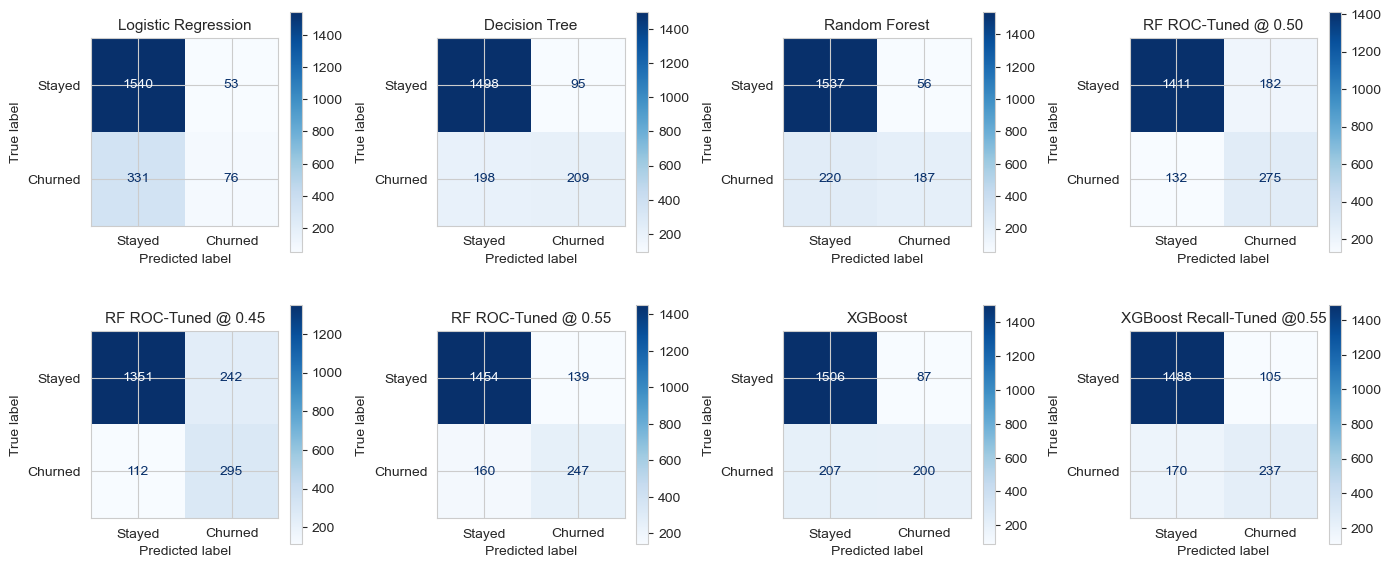

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# List of (model name, y_test, y_pred)
models_conf = [
    ("Logistic Regression", y_test, y_pred_log),
    ("Decision Tree", y_test, y_pred_tree),
    ("Random Forest", y_test, y_pred_rf),
    ("RF ROC-Tuned @ 0.50", y_test, y_pred_rf_tuned_050),
    ("RF ROC-Tuned @ 0.45", y_test, y_pred_rf_tuned_045),
    ("RF ROC-Tuned @ 0.55", y_test, y_pred_rf_tuned_055),
    ("XGBoost", y_test, y_pred_xgb),
    ("XGBoost Recall-Tuned @0.55", y_test, y_pred_xgb_055)
]

# Create 3x3 grid of subplots for the 8 models
fig, axes = plt.subplots(2, 4, figsize=(14,6))  # Adjust grid size if needed
axes = axes.ravel()                               # Flatten 2D array of axes into 1D list for easier indexing

# Loop through each model and plot its confusion matrix
for i, (name, y_true, y_pred) in enumerate(models_conf):
    cm = confusion_matrix(y_true, y_pred)        # Compute the confusion matrix

    # Create and plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Churned"])
    disp.plot(ax=axes[i], cmap="Blues", values_format="d")
    axes[i].set_title(name, fontsize=11)

plt.tight_layout()
plt.show()

## Final Model Performance Comparison

After visualizing the confusion matrices, we now turn to a quantitative comparison across all models using key classification metrics.

This summary table includes:

* **Accuracy** – Overall proportion of correct predictions
* **Precision** – Of those predicted to churn, how many actually did
* **Recall** – Of all actual churners, how many we correctly identified
* **F1 Score** – Harmonic mean of precision and recall, balancing the two
* **ROC-AUC** – Measures how well the model ranks positive vs. negative cases

These metrics allow us to directly compare how well each model performed on the test data – especially in their ability to detect churners while limiting false alarms.


In [99]:
# Store evaluation results for all final models in a list of lists
results = [
    ["Logistic Regression", accuracy_score(y_test, y_pred_log),
     precision_score(y_test, y_pred_log),
     recall_score(y_test, y_pred_log),
     f1_score(y_test, y_pred_log),
     roc_auc_score(y_test, log_clf.predict_proba(X_test_scaled)[:, 1])],

    ["Decision Tree", accuracy_score(y_test, y_pred_tree),
     precision_score(y_test, y_pred_tree),
     recall_score(y_test, y_pred_tree),
     f1_score(y_test, y_pred_tree),
     roc_auc_score(y_test, tree_clf.predict_proba(X_test)[:, 1])],

    ["Random Forest", accuracy_score(y_test, y_pred_rf),
     precision_score(y_test, y_pred_rf),
     recall_score(y_test, y_pred_rf),
     f1_score(y_test, y_pred_rf),
     roc_auc_score(y_test, rf_clf.predict_proba(X_test)[:, 1])],

    ["RF ROC-Tuned @ 0.50", accuracy_score(y_test, y_pred_rf_tuned_050),
     precision_score(y_test, y_pred_rf_tuned_050),
     recall_score(y_test, y_pred_rf_tuned_050),
     f1_score(y_test, y_pred_rf_tuned_050),
     roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])],

    ["RF ROC-Tuned @ 0.45", accuracy_score(y_test, y_pred_rf_tuned_045),
     precision_score(y_test, y_pred_rf_tuned_045),
     recall_score(y_test, y_pred_rf_tuned_045),
     f1_score(y_test, y_pred_rf_tuned_045),
     roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])],

    ["RF ROC-Tuned @ 0.55", accuracy_score(y_test, y_pred_rf_tuned_055),
     precision_score(y_test, y_pred_rf_tuned_055),
     recall_score(y_test, y_pred_rf_tuned_055),
     f1_score(y_test, y_pred_rf_tuned_055),
     roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])],

    ["XGBoost", accuracy_score(y_test, y_pred_xgb),
     precision_score(y_test, y_pred_xgb),
     recall_score(y_test, y_pred_xgb),
     f1_score(y_test, y_pred_xgb),
     roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])],

    ["XGBoost @ 0.55 (Recall-Tuned)", accuracy_score(y_test, y_pred_xgb_055),
     precision_score(y_test, y_pred_xgb_055),
     recall_score(y_test, y_pred_xgb_055),
     f1_score(y_test, y_pred_xgb_055),
     roc_auc_score(y_test, y_proba_xgb_055)]
]

# Convert results to DataFrame for easy viewing
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])

# Round all values to 3 decimals
results_df = results_df.round(3)

# Sort the table by Recall score to prioritize churn detection performance
results_df.sort_values("Recall", ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,RF ROC-Tuned @ 0.45,0.823,0.549,0.725,0.625,0.863
1,RF ROC-Tuned @ 0.50,0.843,0.602,0.676,0.637,0.863
2,RF ROC-Tuned @ 0.55,0.850,0.640,0.607,0.623,0.863
3,XGBoost @ 0.55 (Recall-Tuned),0.862,0.693,0.582,0.633,0.869
4,Decision Tree,0.854,0.688,0.514,0.588,0.830
5,XGBoost,0.853,0.697,0.491,0.576,0.829
6,Random Forest,0.862,0.770,0.459,0.575,0.855
7,Logistic Regression,0.808,0.589,0.187,0.284,0.775


## Final Decision & Critical Review

When comparing the various machine learning models, it becomes clear that each model excels in a different area, and the best choice ultimately depends on our strategic priorities.

### Most Balanced Trade-Off: Random Forest ROC-Tuned @ 0.50

This model offers the most well-rounded performance across metrics. With a precision of 60.2%, recall of 67.6%, and the highest F1-score 63.7% among all models, it effectively balances false positives and false negatives.

It's the ideal choice when the goal is to target churners effectively, without over-alerting the marketing or customer success teams. If resource efficiency and predictive reliability are both important, this is a strong candidate.

### Best Overall Performance: XGBoost @ 0.55 (Recall-Tuned)

From an overall metrics standpoint, this model stands out as the top performer. It delivers:

* The highest accuracy 86.2%
* The best precision 69.3% – meaning fewer false alarms
* The strongest ROC-AUC 86.9% – indicating robust classification performance

This makes XGBoost @ 0.55 a powerful, conservative model: it may miss a few churners, but the predictions it makes are more trustworthy. This is the best option when the goal is low-risk, high-confidence targeting, such as in limited-budget retention programs.

**Final Recommendation**

* If balanced performance is preferred → Go with RF ROC-Tuned @ 0.50
* If high precision and reliability matter most → Pick XGBoost @ 0.55








## Feature Importance Analysis Across Final Models

In order to better understand what drives customer churn predictions, we compared the top features used by our three best-performing models.

* Random Forest – ROC-AUC Tuned (threshold = 0.50)
* XGBoost – Recall-Tuned (threshold = 0.55)

Each model was trained with slightly different optimization goals (ROC-AUC vs Recall), which also influenced the way feature importance is interpreted

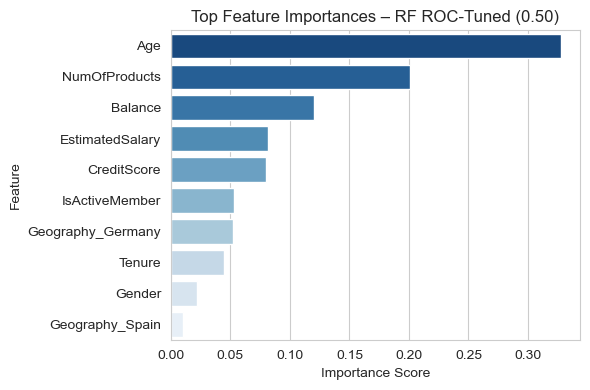

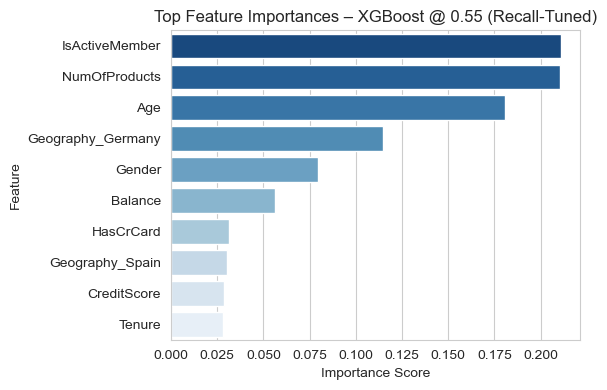

In [100]:
# Create feature importance DataFrames
df_rf_roc = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
df_xgb = pd.Series(best_xgb_recall.feature_importances_, index=X.columns).sort_values(ascending=False)

# Plotting function
def plot_feature_importance(series, title):
    plt.figure(figsize=(6, 4))
    sns.barplot(x=series.values[:10], y=series.index[:10], palette="Blues_r")
    plt.title(title)
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# Plot all three
plot_feature_importance(df_rf_roc, "Top Feature Importances – RF ROC-Tuned (0.50)")
plot_feature_importance(df_xgb, "Top Feature Importances – XGBoost @ 0.55 (Recall-Tuned)")

### Key Observations

To better understand what drives customer churn, we analyzed the most important features identified by our top-performing models and cross-validated those findings with behavioral patterns in the data.

When comparing models, it’s not only about prediction accuracy — we also want to understand what the models learn from the data. For a churn prediction model to be truly useful for a bank, it’s crucial to interpret which features the model relies on most when making its decisions.

At the end of the project, we compared the internal feature importance rankings of our two best-performing models:

* **Random Forest (ROC-AUC Tuned, threshold = 0.50)**

* **XGBoost (Recall-oriented, threshold = 0.55)**

Each model was trained with slightly different optimization goals (ROC-AUC vs Recall), which also shaped how they assess and weigh the input features. The aim was to uncover what drives churn most strongly, and how this connects to actual customer behavior and business insights.

**Age**

In the Random Forest model, Age emerged as the most important feature by far. This matches our earlier EDA findings, where we discovered a strong link between age and churn behavior.

According to our data:

* Customers aged 50–60 had the highest churn rate (~56%)
* Those aged 40–50 and 60–70 also had high churn rates (34% and 31% respectively)
* In contrast, customers under 40 and above 70 had much lower churn (generally below 12%)

This U-shaped pattern suggests that middle-aged customers may be more vulnerable to churn — possibly due to life transitions, financial shifts, or higher sensitivity to competitive offers. They might also be more experienced with financial products and less hesitant to switch banks.

The 40–70 age group represents a high-risk segment. Targeted retention campaigns, loyalty programs, or personalized financial advice could have the most impact here.

**Number of Products**

This feature was ranked highly in both models, but what's most interesting is its non-linear relationship with churn.

According to our data:

* Customers with 1 product had a churn rate of ~27.7%
* Those with 2 products had the lowest churn (~7.6%)
* Churn spiked to 82.7% for customers with 3 products
* And reached 100% for those with 4 products (though this group is very small)

This shows that churn risk doesn’t increase gradually. Instead, both under-engaged and over-engaged customers are at higher risk:

* 1-product users may be weakly connected to the bank and easily leave.
* 3–4 product users might feel overwhelmed, have complex accounts, or experience friction — which leads to dissatisfaction.

The “sweet spot” is clearly 2 products. Customers with fewer or more than this may need proactive attention: onboarding support for the former, and simplification or personalized service for the latter.

**IsActiveMember – Behavior Over Balance**

The recall-tuned XGBoost model ranked IsActiveMember as the most important predictor — even more than Age.

Churn rates by activity level:

* Active members → 14.3% churn
* Inactive members → 26.9% churn

This is a strong binary signal that models — especially boosting algorithms — can exploit very effectively. Since XGBoost builds trees sequentially, it favors such clean, early splits that drastically reduce error. Whether a customer is active or not is a direct reflection of engagement and is often a leading indicator of churn.

Inactivity should trigger immediate attention. An inactive customer may already be halfway out the door — and catching them early is key to retention.

### Model-Specific Priorities – What They Focus On

Feature importance is model-specific, it’s important to note that models don't learn the same way, even if trained on the same data. Their internal logic leads them to focus on different types of splits and decisions.

**Random Forest:** Measures how much each feature reduces impurity across all trees. Tends to favor numeric features used in early splits. Ideal when balance between precision and recall is the goal.

**XGBoost:** Uses gain-based importance — how much a feature reduces error in each boosting round. A clear binary split like active/inactive can dramatically reduce error in early stages. Ideal when early churn detection is critical, even if it comes with some false positives.

The contrast between the two models highlights a core principle in machine learning:
It’s not just what the model predicts, but why.

That’s why even with the same data, each model forms a different understanding of churn risk — which is exactly why model comparison and interpretation are so important.